---

# SAVING PLOTS & FURTHER EXPLORATION

---

>You can **save plots** as images with the `.figure.savefig()` method

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
retail = pd.read_csv('Data/retail_2016_2017.csv', parse_dates=['date'])

retail = (retail
    .query("family in ['DAIRY', 'POULTRY'] and date.dt.year == 2016 and date.dt.month == 3")
    .pivot_table(index=retail['date'].dt.date, columns='family', values='sales', aggfunc='sum')
    .astype('int')
)

retail.head()

family,DAIRY,POULTRY
date,,
2016-03-01,50067,25350
2016-03-02,49731,21372
2016-03-03,38585,17376
2016-03-04,44098,27077
2016-03-05,61647,26651


AttributeError: 'numpy.ndarray' object has no attribute 'figure'

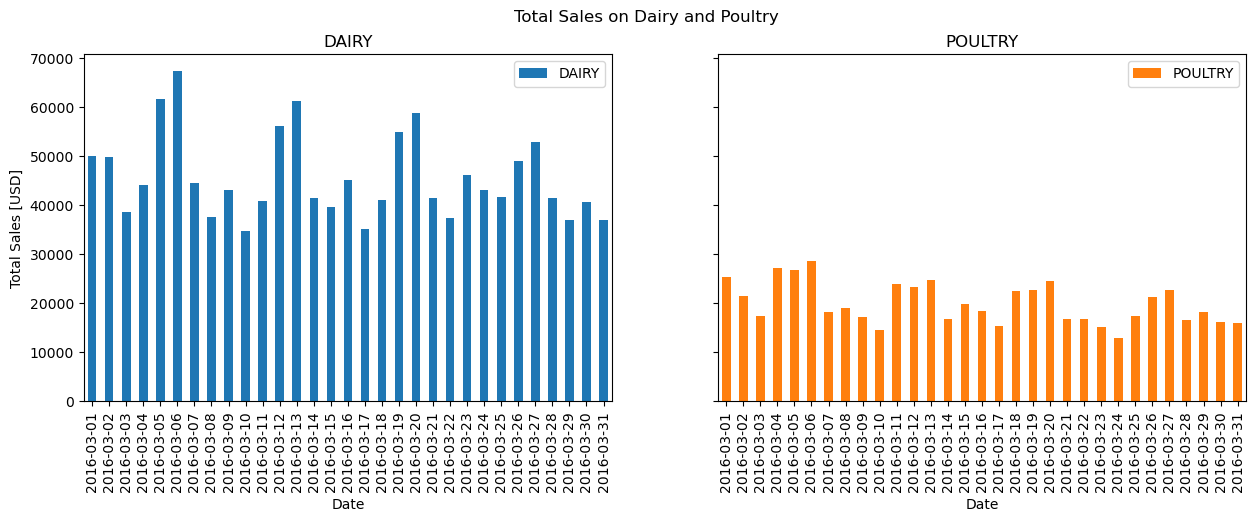

In [3]:
plot = (retail.plot.bar(
    figsize=(15,4.5),
    subplots=True,
    layout=(1,2),
    sharey=True,
    title=('Total Sales on Dairy and Poultry'),
    xlabel=('Date'),
    ylabel=('Total Sales [USD]'),
    rot=90)
)

plot.figure.savefig('Total Sales on Dairy & Poultry', bbox_inches='tight')

---

El problema está en lo que retorna `.plot.bar()` cuando usas `subplots=True`.

>- Cuando llamas a `DataFrame.plot.bar()` sin `subplots=True`, **Pandas retorna un solo objeto Axes de Matplotlib — y ese objeto sí tiene `.figure`.
>
>- Pero cuando usas `subplots=True`, Pandas necesita retornar **múltiples objetos `Axes`** (uno por columna), así que retorna un `numpy.ndarray` de objetos `Axes`. Y un `ndarray` no tiene atributo `.figure` — de ahí el error.

<br><br>

>---
>
>Tienes dos opciones limpias:
>Opción A — Acceder a la figura desde cualquier Axes del array:
```python
plot = (retail.plot.bar(
    figsize=(15, 4.5),
    subplots=True,
    layout=(1, 2),
    sharey=True,
    title=('Total Sales on Dairy and Poultry'),
    xlabel=('Date'),
    ylabel=('Total Sales [USD]'),
    rot=90
))

# plot es un ndarray de Axes → accedemos al primero para obtener la figura
plot[0][0].figure.savefig('Total Sales on Dairy & Poultry.png', bbox_inches='tight')

```

## Entendiendo la indexación de plot[0][0]

>Entender esto te va a servir para siempre que trabajes con subplots.
>El contexto: tu layout=(1, 2)
>Cuando defines layout=(1, 2), le dices a Matplotlib:
>
>- 1 fila
>- 2 columnas
>
>Entonces el `ndarray`` que retorna tiene forma `(1, 2)` — una matriz de 1 fila y 2 columnas.

### Cómo se indexa esa matriz

| row | columna 0 | columna 1 |
|:---|:---:|:---:|
|fila 0 | [ Axes(DAIRY) | Axes(POULTRY) ]|


>Por eso:
>
>- `plot[0][0]` → Axes de DAIRY (fila 0, columna 0)
>- `plot[0][1]` → Axes de POULTRY (fila 0, columna 1)
>
>Para tu caso de `savefig`, **da igual cuál uses** — ambos pertenecen a la misma figura. El `.figure` de cualquier `Axes` hijo siempre apunta al mismo objeto `Figure` padre.
>
>Cómo verificarlo tú mismo (lo más importante)
>
>Nunca adivines — pregúntale al objeto:

In [4]:
# Ver la forma del array
print(plot.shape)        # → (1, 2)

# Ver qué hay en cada posición
print(type(plot[0][0]))  # → <class 'matplotlib.axes._axes.Axes'>
print(type(plot[0][1]))  # → <class 'matplotlib.axes._axes.Axes'>

# Confirmar que ambos apuntan a la misma figura
print(plot[0][0].figure is plot[0][1].figure)  # → True

(1, 2)
<class 'matplotlib.axes._axes.Axes'>
<class 'matplotlib.axes._axes.Axes'>
True


<br><br>

>---
>Opción B — Usar `plt.gcf()` (get current figure), más idiomática:

```python
import matplotlib.pyplot as plt

plot = (retail.plot.bar(
    figsize=(15, 4.5),
    subplots=True,
    layout=(1, 2),
    sharey=True,
    title=('Total Sales on Dairy and Poultry'),
    xlabel=('Date'),
    ylabel=('Total Sales [USD]'),
    rot=90
))

plt.savefig('Total Sales on Dairy & Poultry.png', bbox_inches='tight')

```

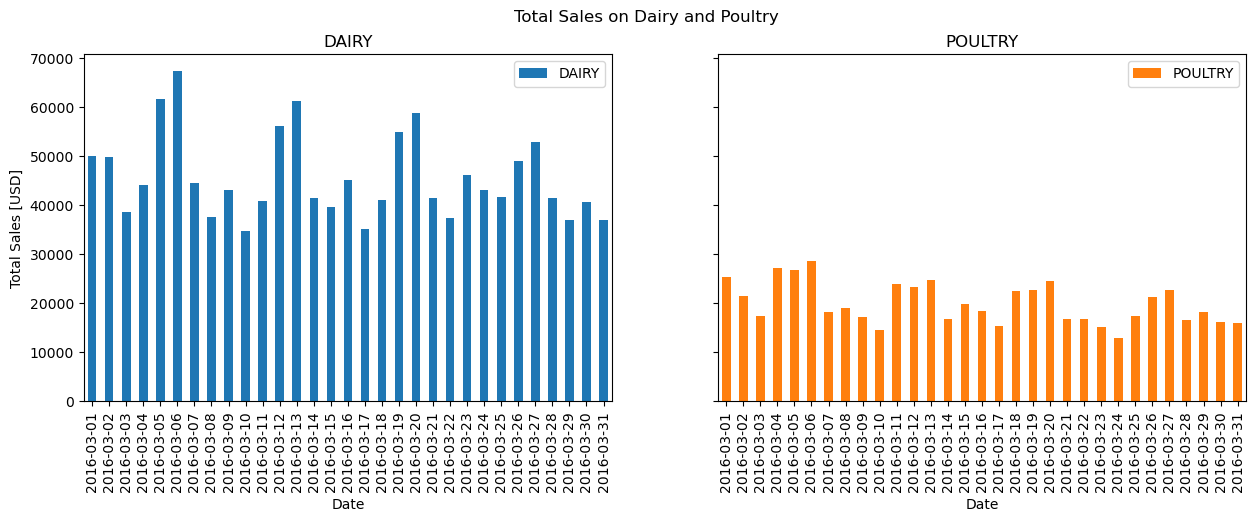

In [5]:
plot = (retail.plot.bar(
    figsize=(15,4.5),
    subplots=True,
    layout=(1,2),
    sharey=True,
    title=('Total Sales on Dairy and Poultry'),
    xlabel=('Date'),
    ylabel=('Total Sales [USD]'),
    rot=90)
)

plot[0][1].figure.savefig('Total Sales on Dairy & Poultry', bbox_inches='tight')